In [1]:
import torch
import numpy as np
from matplotlib import pyplot as plt

import utilities as utils
import care

In [2]:
# --!--------------------------------------------------------------------------
# --! prepare a dataset for the local operator

# --! define known data properties
timeseries_len  = 200
timestep        = 0.001
dataset_dir     = 'cavity/train_24Hz_10Hz_trans'
x_len           = 200

# --! read data from files
data_train = utils.read_datafile(f'{dataset_dir}/train1', timeseries_len)
data_valid = utils.read_datafile(f'{dataset_dir}/valid', timeseries_len)
data_test = utils.read_datafile(f'{dataset_dir}/test', timeseries_len)

# --! data channels are expected to contain:
# --! 1. displacement
x_dims_n = 1

# --! compile dataset parameters
data_table = [
    ( 'dataset',           'batches',        'timeseries length',          'channels'),
    ('--------',           '-------',        '-----------------',          '--------'),
    (   'train', data_train.shape[0], data_train.shape[1], data_train.shape[2]),
    (   'valid', data_valid.shape[0], data_valid.shape[1], data_valid.shape[2]),
    (    'test',  data_test.shape[0],  data_test.shape[1],  data_test.shape[2]) ]

# --! print dataset parameters
print('inf >> dataset parameters:')
print('')
for row in data_table:
    print(f'{row[0]:>8} {row[1]:>8} {row[2]:>18} {row[3]:>8}')

inf >> dataset parameters:

 dataset  batches  timeseries length channels
--------  -------  ----------------- --------
   train     3500                200        1
   valid     1000                200        1
    test      500                200        1


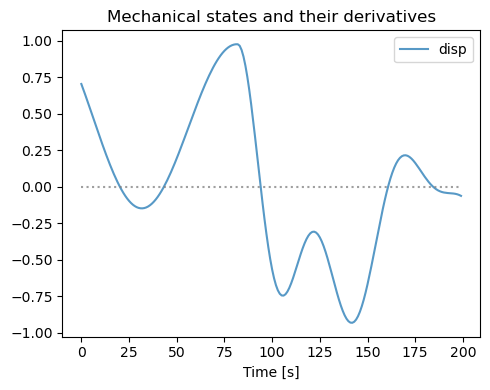

In [3]:
# --!--------------------------------------------------------------------------
# --! visualize loaded data

data_i = 16
data_viz = data_train[data_i]
t_viz = torch.linspace(0., timestep*timeseries_len, timeseries_len)
zero_viz = torch.zeros_like(t_viz)

plt.figure(figsize=(5, 4))
plt.title('Mechanical states and their derivatives')
plt.plot(data_viz[:, 0], color='tab:blue', alpha=0.75, label='disp')
plt.plot(zero_viz, color='tab:gray', linestyle='dotted', alpha=0.75)
plt.legend()
plt.xlabel('Time [s]')
plt.tight_layout()
plt.show()

In [4]:
# --!--------------------------------------------------------------------------
# --! load a trained global model

model = torch.load('data/models/care_global.pt', weights_only=False)

print(model.timeseries_dyn.weight)

Parameter containing:
tensor([[-0.5027, -0.3948,  0.6977, -0.3135],
        [ 0.5441, -0.0349,  0.7912,  0.0805],
        [ 0.4147, -0.3830, -0.0853, -0.3076],
        [ 0.0388,  0.5975, -0.0408, -0.6407]], requires_grad=True)


inf >> Number of data files for training : 7
inf >> processing training file number 1
inf >> processing training file number 2
inf >> processing training file number 3
inf >> processing training file number 4
inf >> processing training file number 5
inf >> processing training file number 6
inf >> processing training file number 7


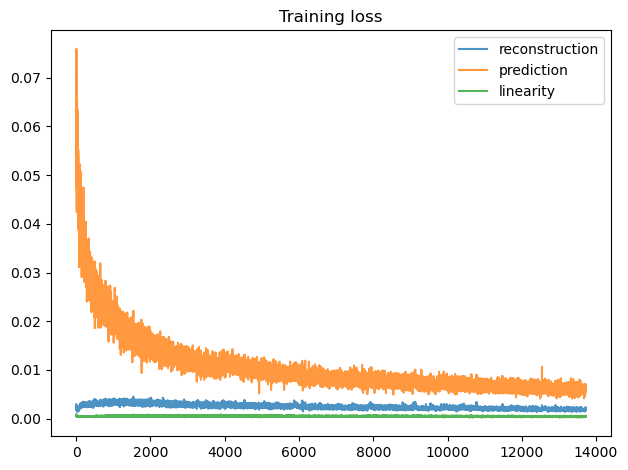

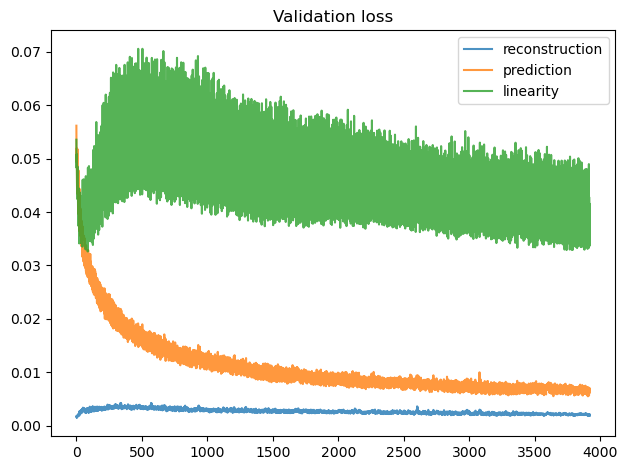

inf >> reconstruction loss in training is 2.492099e-03
inf >> prediction loss in training is 1.068095e-02
inf >> linearity loss in training is 4.916652e-04


In [5]:
# --!--------------------------------------------------------------------------
# --! training and validation of the local Koopman operator

# --! we train the local operator now, so freeze the global one
utils.freeze_module(model.timeseries_dyn)
utils.unfreeze_module(model.funs_dyn_enc)
utils.unfreeze_module(model.funs_dyn)

alpha = 0.5

bat_sz = 128

# --! specify optimizer
optimizer = torch.optim.Adam(
    filter(lambda param: param.requires_grad, model.parameters()),
    lr=0.001,
    weight_decay=1e-8)

# --! empty arrays to gather statistics
loss_train_recon = []
loss_train_pred  = []
loss_train_lin   = []

loss_valid_recon = []
loss_valid_pred  = []
loss_valid_lin   = []

# --! training duration
datafiles_train_n = 7
epochs_n          = 70
print(f"inf >> Number of data files for training : {datafiles_train_n}")

# --! prepare validation dataset
dataset_valid = torch.utils.data.TensorDataset(data_valid)

for datafile_train in range(datafiles_train_n):
    print(f"inf >> processing training file number {datafile_train + 1}")

    # --! make training datasets and loaders
    data_train = utils.read_datafile(f'{dataset_dir}/train{datafile_train + 1}', timeseries_len)
    dataset_train = torch.utils.data.TensorDataset(data_train)
    dataloader_train = torch.utils.data.DataLoader(dataset_train, batch_size=bat_sz, shuffle=True)

    # --! train
    for epoch in range(epochs_n):

        # --! train neural networks
        for this, data in enumerate(dataloader_train):
            x = data[0][:, :x_len, :1]

            optimizer.zero_grad()

            # --! fit a model to training data
            loss, loss_ae, loss_pred, loss_lin = model.fit(x, global_only=False, alpha=alpha)

            loss.backward()
            optimizer.step()

            with torch.no_grad():
                loss_train_recon.append(loss_ae)
                loss_train_pred.append(loss_pred)
                loss_train_lin.append(loss_lin)

        # --! validate results
        with torch.no_grad():
            dataloader_valid = torch.utils.data.DataLoader(dataset_valid, batch_size=bat_sz, shuffle=False)
            for data in dataloader_valid:
                x  = data[0][:, :x_len, :1] # take only displacement

                # --! validate prediction
                funs, funs_pred, timeseries_recon, timeseries_pred, timeseries_dyn_mat, funs_dyn_mat = model(
                    x, global_only=False, alpha=alpha)
                loss_valid_recon.append(torch.mean((x - timeseries_recon)**2))
                loss_valid_pred.append(torch.mean((x - timeseries_pred)**2))
                loss_valid_lin.append(torch.mean((funs - funs_pred)**2))

# --! display training statistics
with torch.no_grad():
    plt.figure()
    plt.title('Training loss')
    plt.plot(loss_train_recon, alpha=0.8, label='reconstruction')
    plt.plot(loss_train_pred, alpha=0.8, label='prediction')
    plt.plot(loss_train_lin, alpha=0.8, label='linearity')
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure()
    plt.title('Validation loss')
    plt.plot(loss_valid_recon, alpha=0.8, label='reconstruction')
    plt.plot(loss_valid_pred, alpha=0.8, label='prediction')
    plt.plot(loss_valid_lin, alpha=0.8, label='linearity')
    plt.legend()
    plt.tight_layout()
    plt.show()

    loss_train_recon_mean = np.mean(loss_train_recon)
    loss_train_pred_mean = np.mean(loss_train_pred)
    loss_train_lin_mean = np.mean(loss_train_lin)
    print(f'inf >> reconstruction loss in training is {loss_train_recon_mean:e}')
    print(f'inf >> prediction loss in training is {loss_train_pred_mean:e}')
    print(f'inf >> linearity loss in training is {loss_train_lin_mean:e}')

In [37]:
# --!--------------------------------------------------------------------------
# --! gather test statistics

with torch.no_grad():
    # --! make validation datasets and loaders
    dataset_test = torch.utils.data.TensorDataset(data_test)
    dataloader_test = torch.utils.data.DataLoader(dataset_test, batch_size=bat_sz, shuffle=False)

    loss_test_recon = []
    loss_test_pred = []

    for data in dataloader_test:
        x  = data[0][:, :x_len, :x_dims_n]

        funs, funs_pred, timeseries_recon, timeseries_pred, timeseries_dyn_mat, funs_dyn_mat = model(
            x, global_only=False, alpha=alpha)
        loss_test_recon.append(torch.mean((x - timeseries_recon)**2))
        loss_test_pred.append(torch.mean((x - timeseries_pred)**2))

    loss_test_recon_mean = np.mean(loss_test_recon)
    loss_test_pred_mean = np.mean(loss_test_pred)
    print(f'inf >> reconstruction loss in test is {loss_test_recon_mean:e}') # 1.801337e-03
    print(f'inf >> prediction loss in test is {loss_test_pred_mean:e}') # 5.535175e-03

inf >> reconstruction loss in test is 1.801337e-03
inf >> prediction loss in test is 5.535175e-03


tensor([[[-0.5027, -0.3948,  0.6977, -0.3135],
         [ 0.5441, -0.0349,  0.7912,  0.0805],
         [ 0.4147, -0.3830, -0.0853, -0.3076],
         [ 0.0388,  0.5975, -0.0408, -0.6407]]])
tensor([[[1.6528e-02, 8.5561e-01, 1.2284e-01, 5.0195e-03],
         [4.2924e-02, 1.8218e-04, 2.2039e-03, 9.5469e-01],
         [9.3889e-02, 3.7918e-01, 1.4223e-01, 3.8470e-01],
         [3.6225e-02, 8.0746e-01, 1.3543e-01, 2.0884e-02]]])


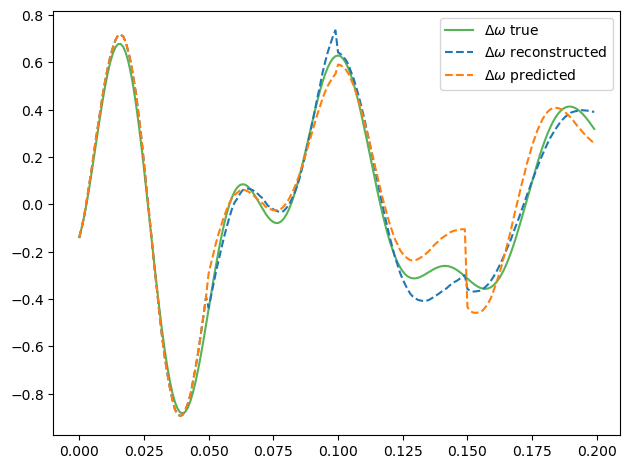

In [36]:
# --!--------------------------------------------------------------------------
# --! test individual results

with torch.no_grad():
    data_i  = 123
    data    = data_test[data_i]

    timeseries = torch.unsqueeze(data[:x_len, :1], dim=0)
    funs, funs_pred, timeseries_recon, timeseries_pred, timeseries_dyn_mat, funs_dyn_mat = model(
        timeseries,
        global_only=False,
        alpha=alpha)

    print(timeseries_dyn_mat)
    print(funs_dyn_mat)

    timeseries = torch.squeeze(timeseries, dim=0)
    timeseries_recon = torch.squeeze(timeseries_recon, dim=0)
    timeseries_pred = torch.squeeze(timeseries_pred, dim=0)

    t = np.arange(0., x_len*timestep, timestep)

    plt.figure()
    plt.plot(t, timeseries[:, 0], alpha=0.8, color='tab:green', label='$\\Delta \\omega$ true')
    plt.plot(t, timeseries_recon[:, 0], alpha=1, color='tab:blue', linestyle='dashed', label='$\\Delta \\omega$ reconstructed')
    plt.plot(t, timeseries_pred[:, 0], alpha=1, color='tab:orange', linestyle='dashed', label='$\\Delta \\omega$ predicted')
    plt.legend()
    plt.tight_layout()
    plt.show()

tensor([[[-0.5027, -0.3948,  0.6977, -0.3135],
         [ 0.5441, -0.0349,  0.7912,  0.0805],
         [ 0.4147, -0.3830, -0.0853, -0.3076],
         [ 0.0388,  0.5975, -0.0408, -0.6407]]])
tensor([[[6.0083e-07, 4.1399e-01, 5.8600e-01, 8.8880e-06],
         [8.7155e-01, 2.3794e-05, 1.7473e-05, 1.2841e-01],
         [8.3662e-01, 2.9175e-05, 2.1250e-05, 1.6333e-01],
         [1.1234e-02, 4.6579e-01, 5.0778e-01, 1.5192e-02]]])


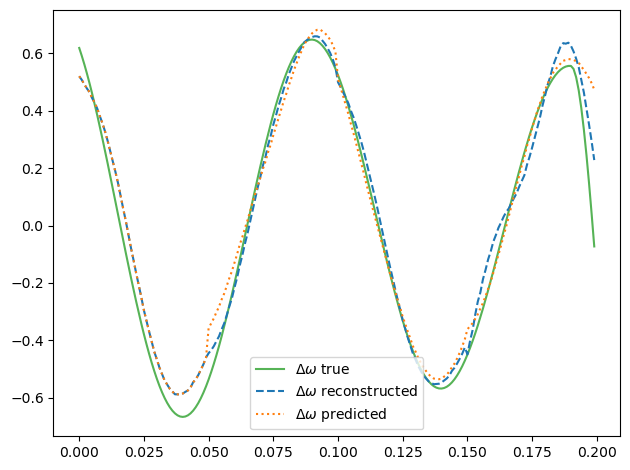

tensor([[[-0.5027, -0.3948,  0.6977, -0.3135],
         [ 0.5441, -0.0349,  0.7912,  0.0805],
         [ 0.4147, -0.3830, -0.0853, -0.3076],
         [ 0.0388,  0.5975, -0.0408, -0.6407]]])
tensor([[[0.0189, 0.5126, 0.4536, 0.0150],
         [0.4296, 0.0391, 0.0531, 0.4782],
         [0.4264, 0.0295, 0.0424, 0.5017],
         [0.0112, 0.5338, 0.4466, 0.0085]]])


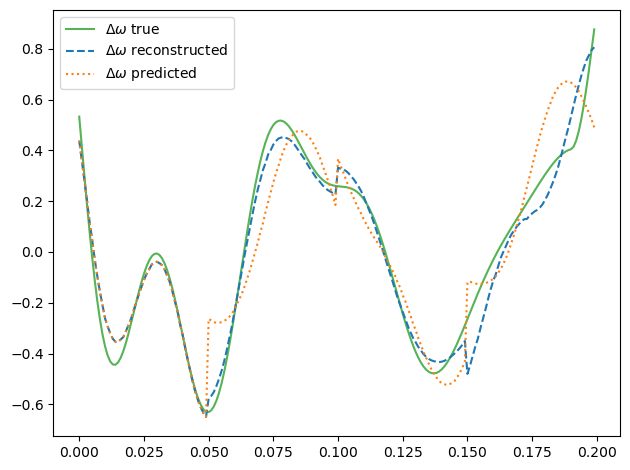

tensor([[[-0.5027, -0.3948,  0.6977, -0.3135],
         [ 0.5441, -0.0349,  0.7912,  0.0805],
         [ 0.4147, -0.3830, -0.0853, -0.3076],
         [ 0.0388,  0.5975, -0.0408, -0.6407]]])
tensor([[[0.0031, 0.1147, 0.8791, 0.0030],
         [0.2630, 0.1010, 0.0805, 0.5555],
         [0.0187, 0.0030, 0.0022, 0.9761],
         [0.1234, 0.3728, 0.4212, 0.0827]]])


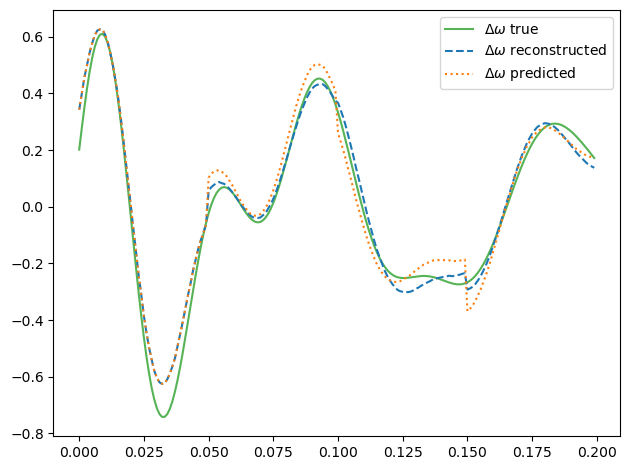

tensor([[[-0.5027, -0.3948,  0.6977, -0.3135],
         [ 0.5441, -0.0349,  0.7912,  0.0805],
         [ 0.4147, -0.3830, -0.0853, -0.3076],
         [ 0.0388,  0.5975, -0.0408, -0.6407]]])
tensor([[[1.1664e-05, 5.0919e-01, 4.9077e-01, 2.9689e-05],
         [6.2546e-01, 8.2799e-05, 8.6467e-05, 3.7437e-01],
         [6.3168e-01, 7.7981e-05, 8.1496e-05, 3.6816e-01],
         [1.3539e-04, 5.0569e-01, 4.9389e-01, 2.8892e-04]]])


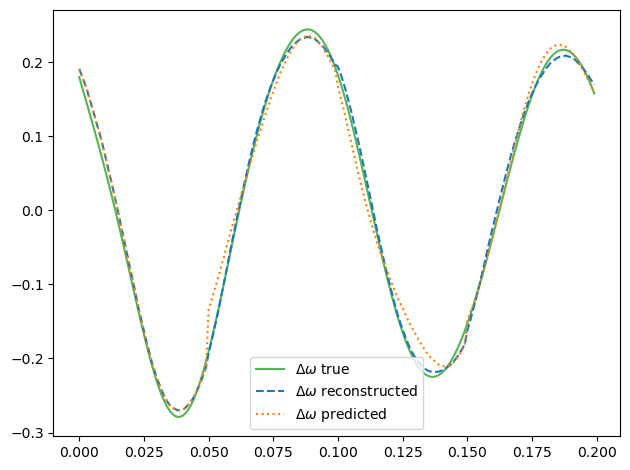

tensor([[[-0.5027, -0.3948,  0.6977, -0.3135],
         [ 0.5441, -0.0349,  0.7912,  0.0805],
         [ 0.4147, -0.3830, -0.0853, -0.3076],
         [ 0.0388,  0.5975, -0.0408, -0.6407]]])
tensor([[[1.9987e-03, 7.3672e-01, 2.6042e-01, 8.5895e-04],
         [3.5543e-01, 1.5608e-04, 9.9791e-04, 6.4341e-01],
         [3.3400e-01, 5.1338e-04, 2.3159e-03, 6.6318e-01],
         [1.5309e-04, 8.3664e-01, 1.6316e-01, 4.8101e-05]]])


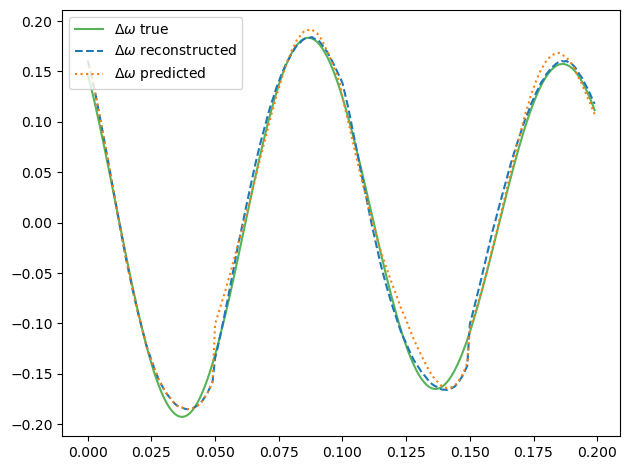

In [38]:
# --!--------------------------------------------------------------------------
# --! evaluate model on long timeseries

eval_ts_len       = 200
eval_timestep     = 0.001
eval_dataset_dir  = 'cavity/eval_10Hz_24Hz'

eval_data = utils.read_datafile(f'{eval_dataset_dir}/eval1', eval_ts_len)

with torch.no_grad():
    data = torch.split(eval_data, 1, dim=0)
    for datum in data:
        outs = model(datum, global_only=False, alpha=alpha)

        print(outs[4])
        print(outs[5])

        timeseries = torch.squeeze(datum, dim=0)
        timeseries_recon = torch.squeeze(outs[2], dim=0)
        timeseries_pred = torch.squeeze(outs[3], dim=0)

        t = np.arange(0., eval_ts_len*eval_timestep, eval_timestep)

        plt.figure()
        plt.plot(t, timeseries[:, 0], alpha=0.8, color='tab:green', label='$\\Delta \\omega$ true')
        plt.plot(t, timeseries_recon[:, 0], alpha=1, color='tab:blue', linestyle='dashed', label='$\\Delta \\omega$ reconstructed')
        plt.plot(t, timeseries_pred[:, 0], alpha=1, color='tab:orange', linestyle='dotted', label='$\\Delta \\omega$ predicted')
        plt.legend()
        plt.tight_layout()
        plt.show()